importing libraries and modules

In [ ]:
import numpy as np
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef

sd_data = pd.read_csv(r"C:\Users\kriti\OneDrive\Desktop\CS\ai_ml\smoking_driking_dataset_Ver01.csv") 
sd_data.describe()


,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,DBP,...,HDL_chole,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd
count,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,...,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000,991346.000000
mean,47.614491,162.240625,63.284050,81.233358,0.980834,0.978429,1.031495,1.030476,122.432498,76.052627,...,56.936800,113.037692,132.141751,14.229824,1.094224,0.860467,25.989308,25.755051,37.136347,1.608122
std,14.181339,9.282957,12.514241,11.850323,0.605949,0.604774,0.174650,0.171892,14.543148,9.889365,...,17.238479,35.842812,102.196985,1.584929,0.437724,0.480530,23.493386,26.308599,50.424153,0.818507
min,20.000000,130.000000,25.000000,8.000000,0.100000,0.100000,1.000000,1.000000,67.000000,32.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.100000,1.000000,1.000000,1.000000,1.000000
25%,35.000000,155.000000,55.000000,74.100000,0.700000,0.700000,1.000000,1.000000,112.000000,70.000000,...,46.000000,89.000000,73.000000,13.200000,1.000000,0.700000,19.000000,15.000000,16.000000,1.000000
50%,45.000000,160.000000,60.000000,81.000000,1.000000,1.000000,1.000000,1.000000,120.000000,76.000000,...,55.000000,111.000000,106.000000,14.300000,1.000000,0.800000,23.000000,20.000000,23.000000,1.000000
75%,60.000000,170.000000,70.000000,87.800000,1.200000,1.200000,1.000000,1.000000,131.000000,82.000000,...,66.000000,135.000000,159.000000,15.400000,1.000000,1.000000,28.000000,29.000000,39.000000,2.000000
max,85.000000,190.000000,140.000000,999.000000,9.900000,9.900000,2.000000,2.000000,273.000000,185.000000,...,8110.000000,5119.000000,9490.000000,25.000000,6.000000,98.000000,9999.000000,7210.000000,999.000000,3.000000


checking the shape and some entries of the data

In [9]:
sd_data.shape
sd_data.head

<bound method NDFrame.head of            sex  age  height  weight  waistline  sight_left  sight_right  \
0         Male   35     170      75       90.0         1.0          1.0   
1         Male   30     180      80       89.0         0.9          1.2   
2         Male   40     165      75       91.0         1.2          1.5   
3         Male   50     175      80       91.0         1.5          1.2   
4         Male   50     165      60       80.0         1.0          1.2   
...        ...  ...     ...     ...        ...         ...          ...   
991341    Male   45     175      80       92.1         1.5          1.5   
991342    Male   35     170      75       86.0         1.0          1.5   
991343  Female   40     155      50       68.0         1.0          0.7   
991344    Male   25     175      60       72.0         1.5          1.0   
991345    Male   50     160      70       90.5         1.0          1.5   

        hear_left  hear_right  SBP  ...  LDL_chole  triglyceride  hem

checking for different data types

In [10]:
sd_data.dtypes

sex                  object
age                   int64
height                int64
weight                int64
waistline           float64
sight_left          float64
sight_right         float64
hear_left             int64
hear_right            int64
SBP                   int64
DBP                   int64
BLDS                  int64
tot_chole             int64
HDL_chole             int64
LDL_chole             int64
triglyceride          int64
hemoglobin          float64
urine_protein         int64
serum_creatinine    float64
SGOT_AST              int64
SGOT_ALT              int64
gamma_GTP             int64
SMK_stat_type_cd      int64
DRK_YN               object
dtype: object

checking for null values

In [11]:
sd_data.isnull().sum()

sex                 0
age                 0
height              0
weight              0
waistline           0
sight_left          0
sight_right         0
hear_left           0
hear_right          0
SBP                 0
DBP                 0
BLDS                0
tot_chole           0
HDL_chole           0
LDL_chole           0
triglyceride        0
hemoglobin          0
urine_protein       0
serum_creatinine    0
SGOT_AST            0
SGOT_ALT            0
gamma_GTP           0
SMK_stat_type_cd    0
DRK_YN              0
dtype: int64

turning categorical data to numbers so thta it is easy to deal with

In [4]:
sd_data['sex'].replace({'Male':1,'Female':0},inplace= True)
sd_data['DRK_YN'].replace({'Y':1,'N':0},inplace=True)
sd_data.head

<bound method NDFrame.head of         sex  age  height  weight  waistline  sight_left  sight_right  \
0         1   35     170      75       90.0         1.0          1.0   
1         1   30     180      80       89.0         0.9          1.2   
2         1   40     165      75       91.0         1.2          1.5   
3         1   50     175      80       91.0         1.5          1.2   
4         1   50     165      60       80.0         1.0          1.2   
...     ...  ...     ...     ...        ...         ...          ...   
991341    1   45     175      80       92.1         1.5          1.5   
991342    1   35     170      75       86.0         1.0          1.5   
991343    0   40     155      50       68.0         1.0          0.7   
991344    1   25     175      60       72.0         1.5          1.0   
991345    1   50     160      70       90.5         1.0          1.5   

        hear_left  hear_right  SBP  ...  LDL_chole  triglyceride  hemoglobin  \
0               1        

dropping the columns with low variance because thye wont be able to tell us much about the data anyways an would add to the features

In [5]:
sd_data.drop(sd_data.columns[[5 , 6 , 7 , 8, 17]], axis=1, inplace=True)
sd_data.head

<bound method NDFrame.head of         sex  age  height  weight  waistline  SBP  DBP  BLDS  tot_chole  \
0         1   35     170      75       90.0  120   80    99        193   
1         1   30     180      80       89.0  130   82   106        228   
2         1   40     165      75       91.0  120   70    98        136   
3         1   50     175      80       91.0  145   87    95        201   
4         1   50     165      60       80.0  138   82   101        199   
...     ...  ...     ...     ...        ...  ...  ...   ...        ...   
991341    1   45     175      80       92.1  114   80    88        198   
991342    1   35     170      75       86.0  119   83    83        133   
991343    0   40     155      50       68.0  110   70    90        205   
991344    1   25     175      60       72.0  119   74    69        122   
991345    1   50     160      70       90.5  133   79    99        225   

        HDL_chole  LDL_chole  triglyceride  hemoglobin  serum_creatinine  \
0    

defining a boxplot plotting function

In [14]:
def plot_boxplot(df,ft):
    df.boxplot(column=[ft])
    plt.grid(False)
    plt.show()

checking to see visually which feature has the maximum outliers or the most imbalanced or skewed distribution

sex


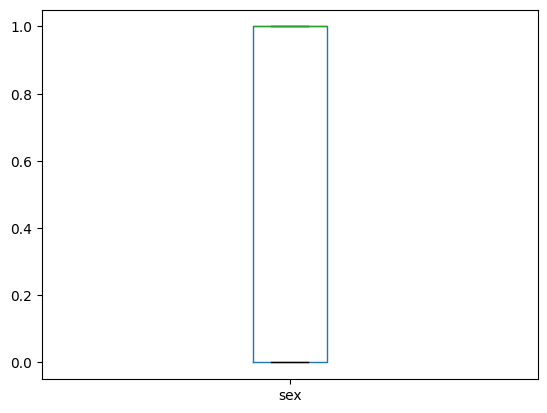

age


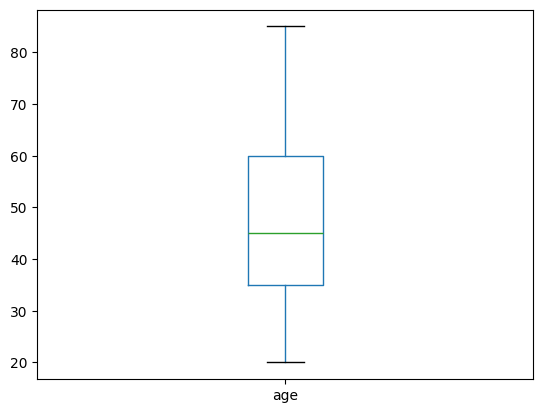

height


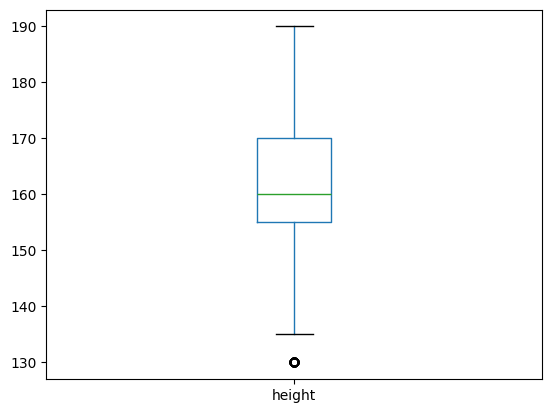

weight


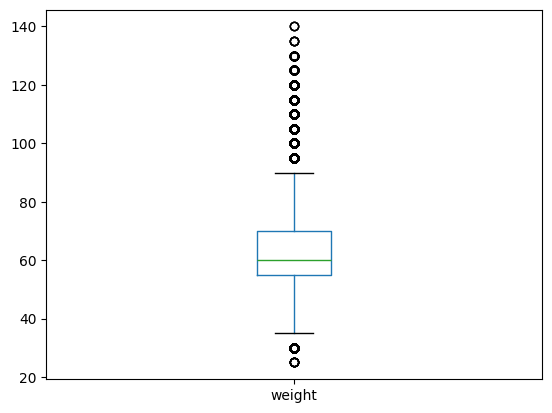

waistline


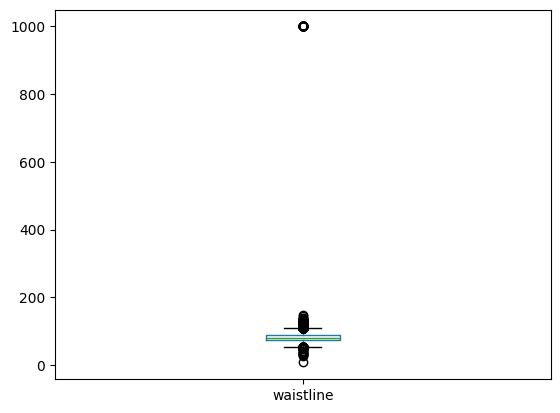

SBP


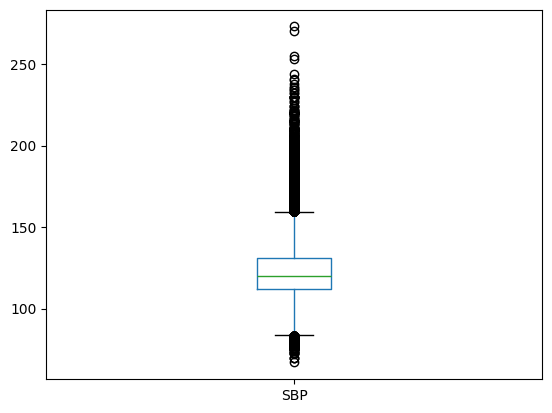

DBP


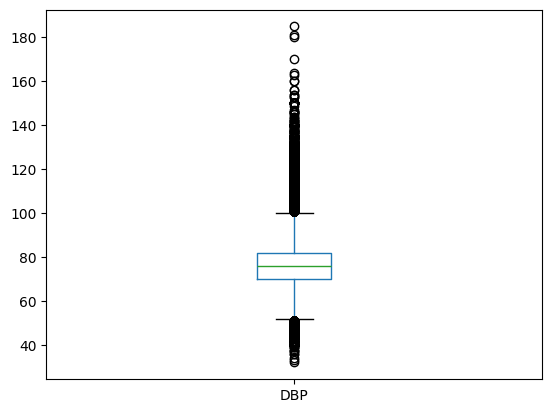

BLDS


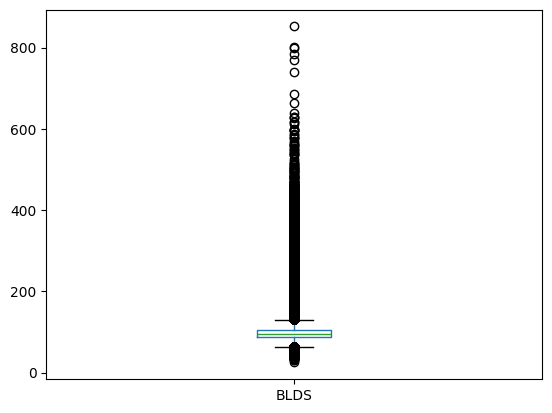

tot_chole


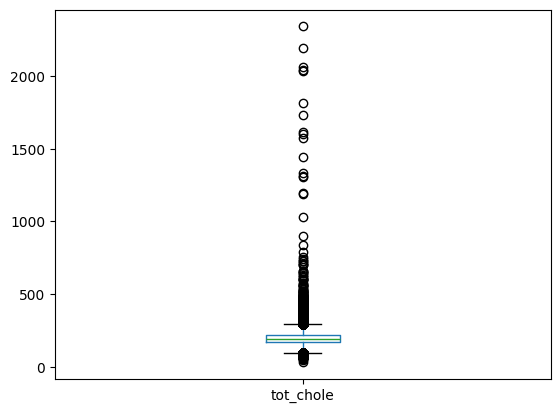

HDL_chole


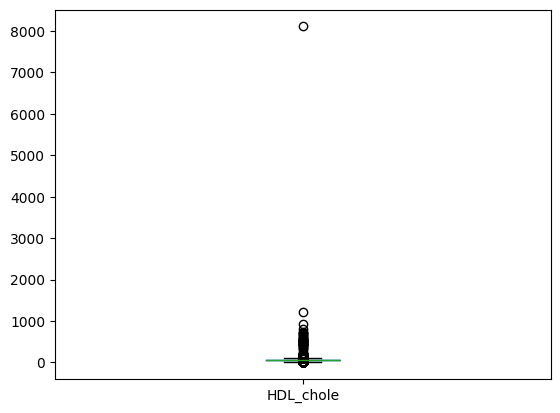

LDL_chole


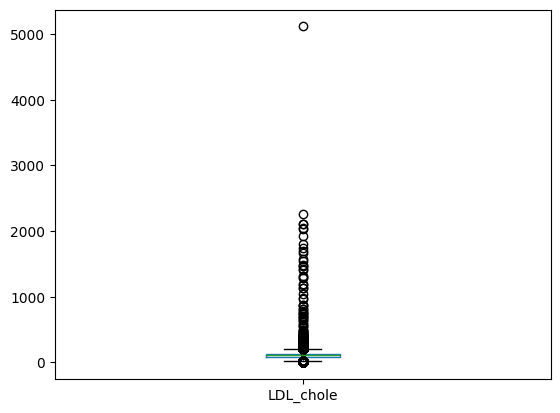

triglyceride


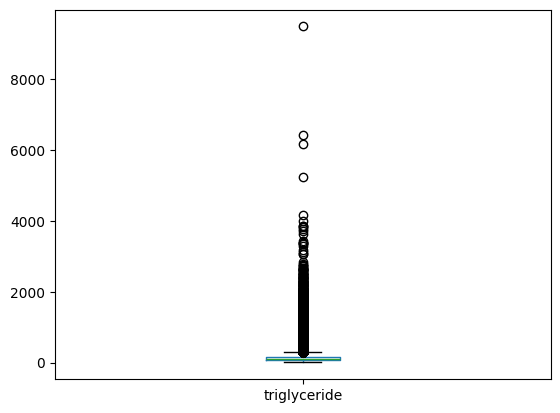

hemoglobin


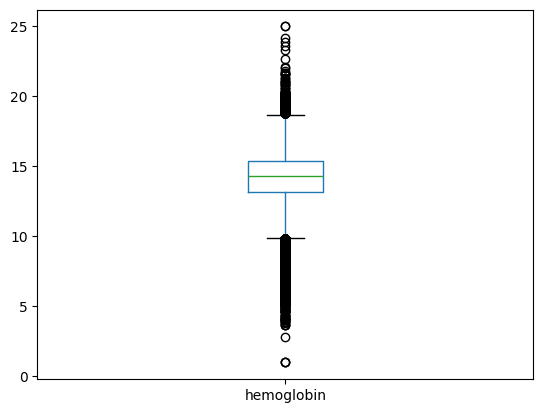

serum_creatinine


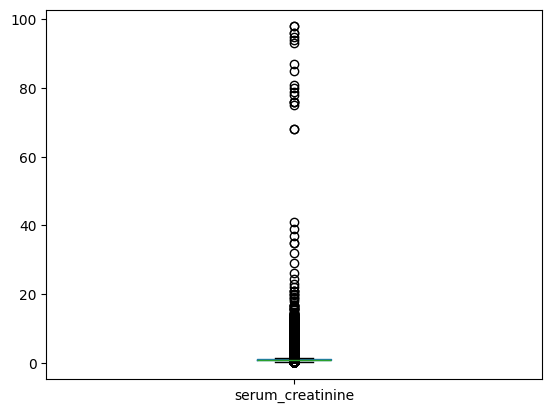

SGOT_AST


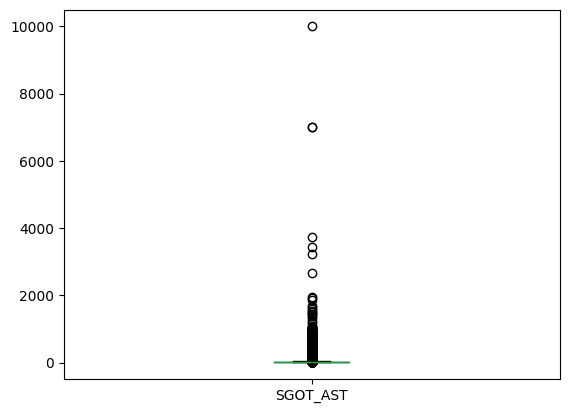

SGOT_ALT


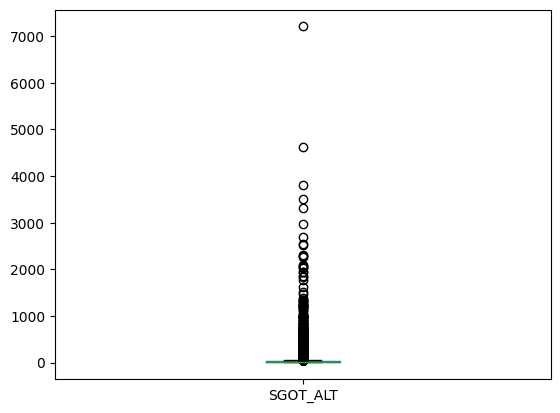

gamma_GTP


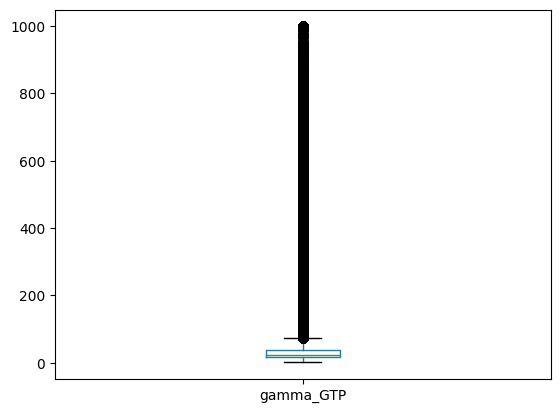

SMK_stat_type_cd


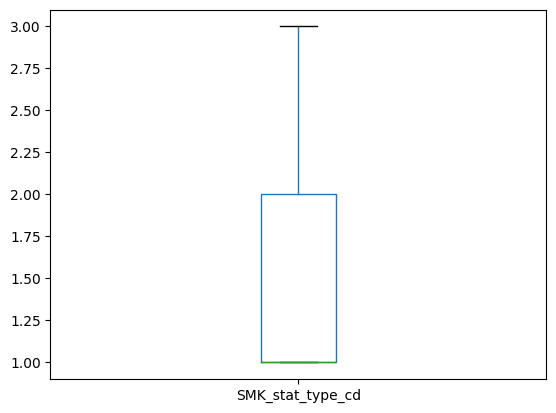

DRK_YN


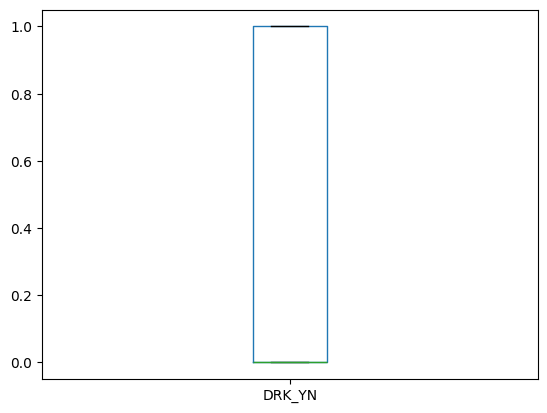

In [15]:
for column in sd_data.columns:
    print(column)
    plot_boxplot(sd_data,column)

defining functions to find the outliers for each feature and remove them

In [6]:
def outliers(df,ft):
    Q1=df[ft].quantile(0.25)
    Q3=df[ft].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1- 5 * IQR
    upper_bound = Q3 + 5 * IQR
    
    ls = df.index[(df[ft] < lower_bound) | (df[ft] > upper_bound)]
    
    return ls

def remove(df,ls):
    ls = sorted(set(ls))
    df = df.drop(ls)
    return df

checking for outliers in each column which either has very high variace or weirdly high maximum values( waistline for eg.)

In [7]:
index_list = []
for feature in ['waistline','SBP','DBP','tot_chole','HDL_chole','LDL_chole','triglyceride','serum_creatinine','SGOT_AST','SGOT_ALT','gamma_GTP']:
    index_list.extend(outliers(sd_data,feature))
    sd_cleaned = remove(sd_data, index_list)

checking the state of the new database created

In [18]:
sd_cleaned.describe()
sd_cleaned.shape

(949236, 19)

plotting boxplot again to see how much they have changed

sex


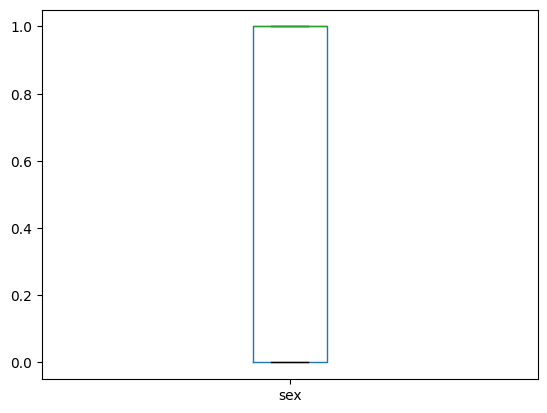

age


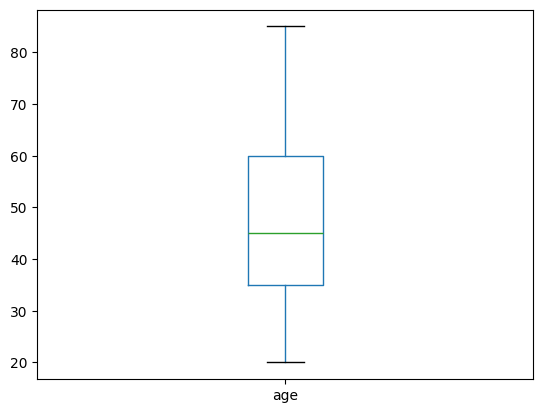

height


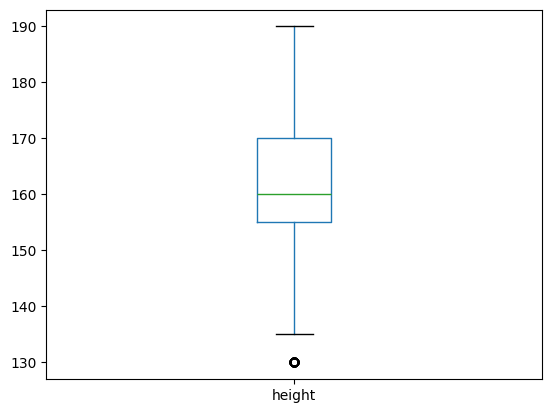

weight


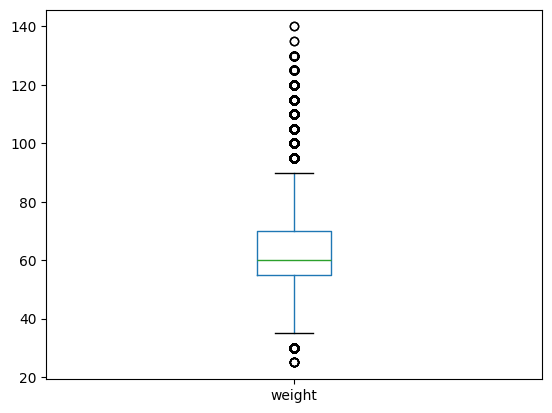

waistline


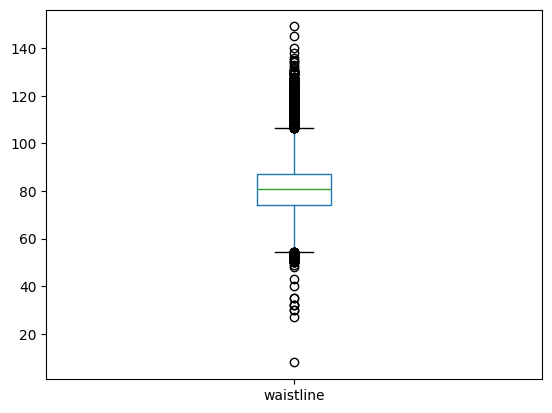

SBP


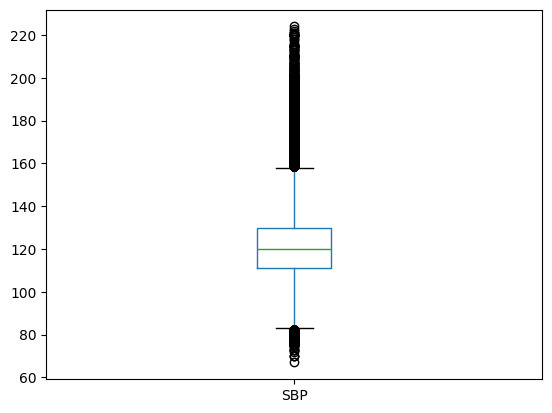

DBP


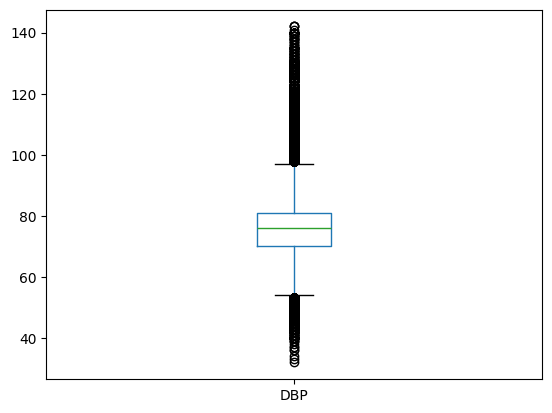

BLDS


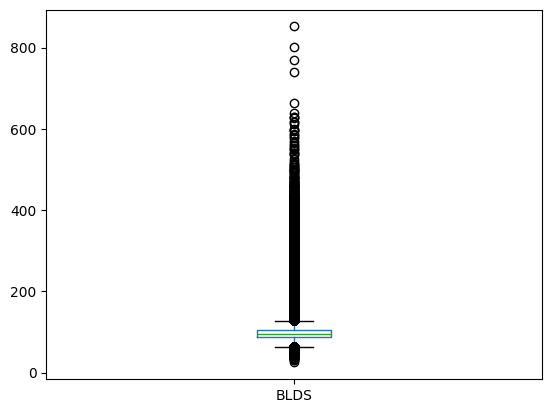

tot_chole


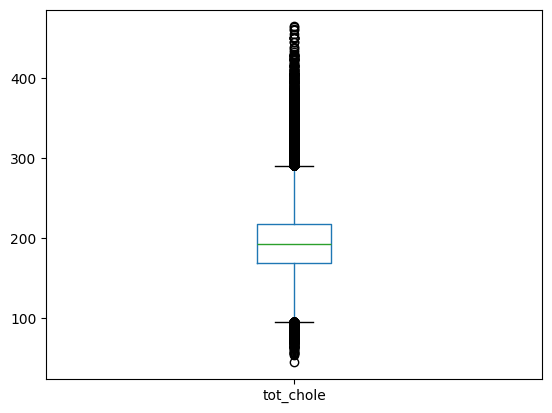

HDL_chole


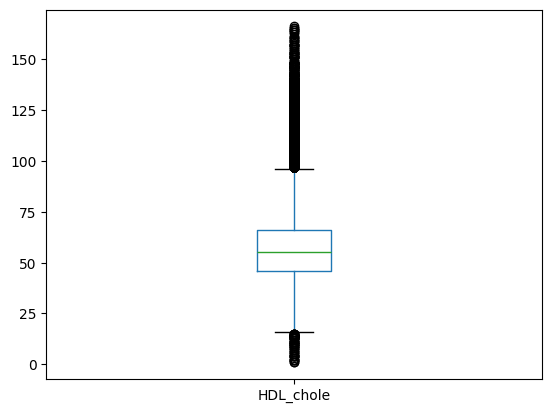

LDL_chole


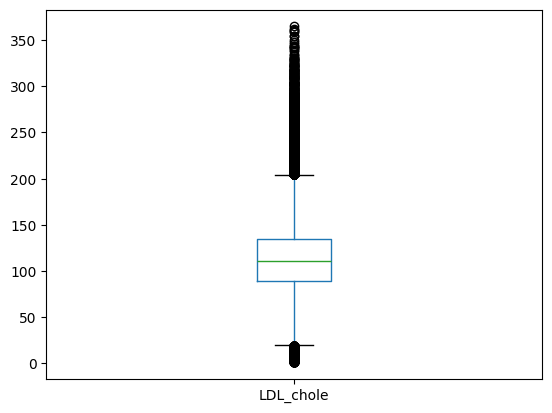

triglyceride


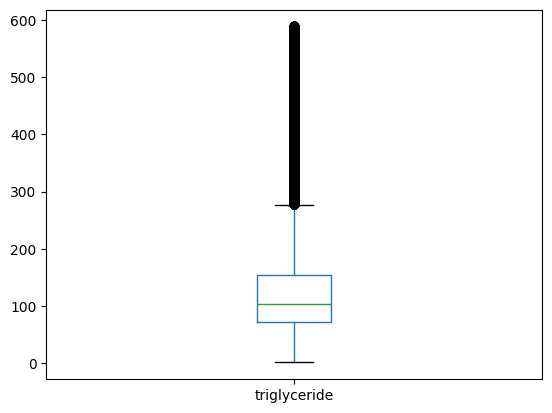

hemoglobin


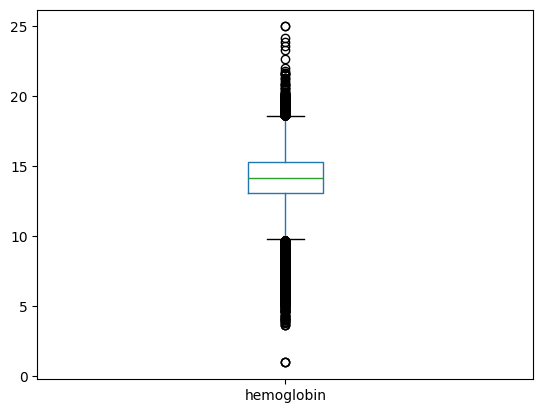

serum_creatinine


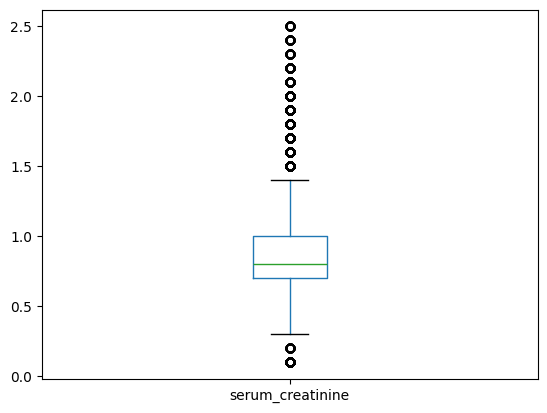

SGOT_AST


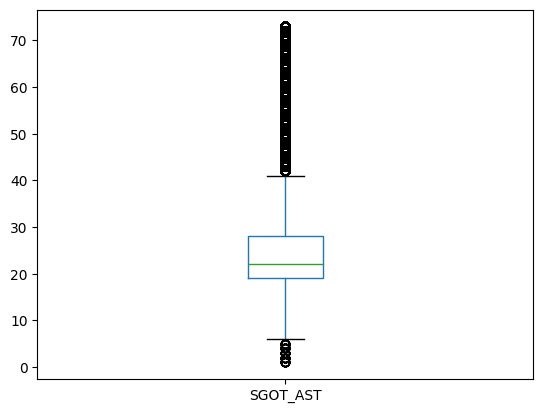

SGOT_ALT


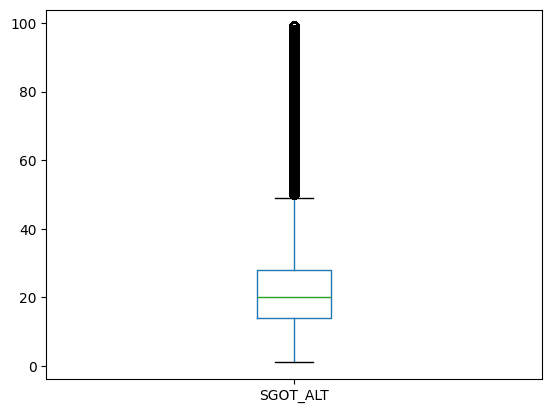

gamma_GTP


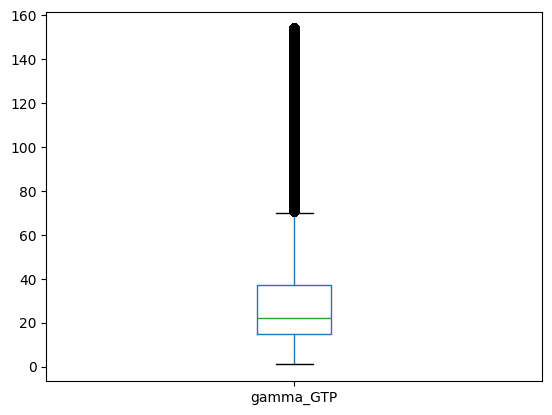

SMK_stat_type_cd


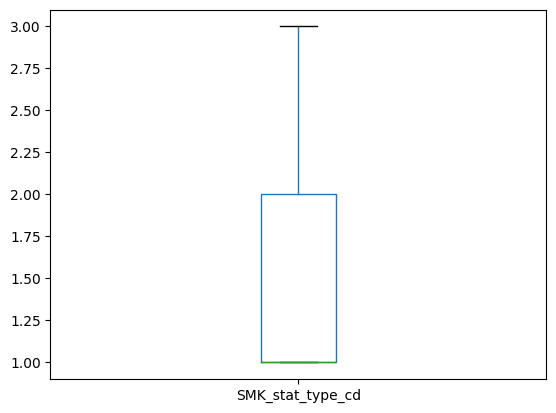

DRK_YN


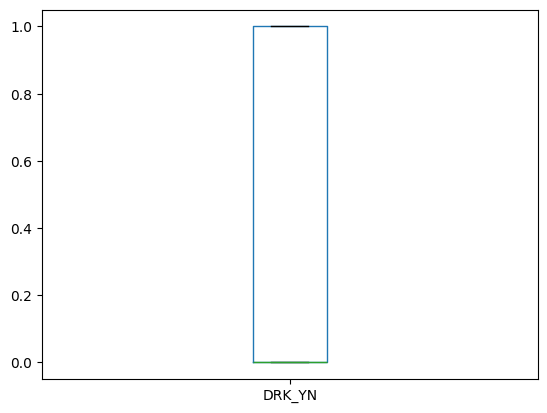

In [19]:
for column in sd_cleaned.columns:
    print(column)
    plot_boxplot(sd_cleaned,column)

checking correlation in our data

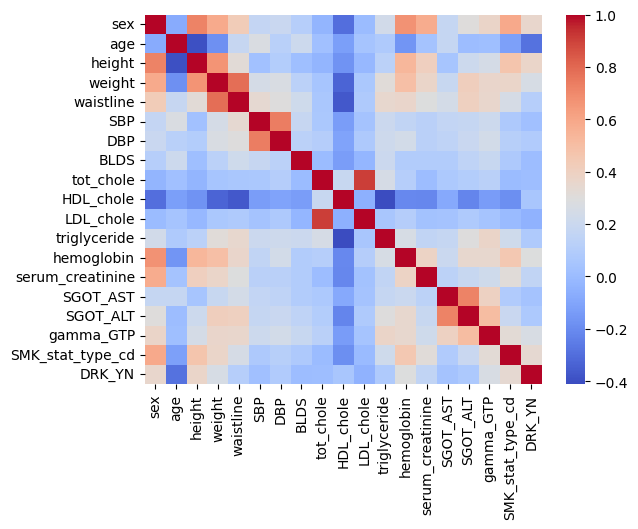

In [20]:
sd_cleaned.corr()
sns.heatmap(sd_cleaned.corr(), cmap='coolwarm')
plt.show()

making a new column so that we can a model guess both smoking and drinking at the same time

In [8]:
def new_column(row):
    if row['DRK_YN'] == 0 and row['SMK_stat_type_cd'] == 1:
        return 0
    elif row['DRK_YN'] == 0 and row['SMK_stat_type_cd'] == 2:
        return 1
    elif row['DRK_YN'] == 0 and row['SMK_stat_type_cd'] == 3:
        return 2
    elif row['DRK_YN'] == 1 and row['SMK_stat_type_cd'] == 1:
        return 3
    elif row['DRK_YN'] == 1 and row['SMK_stat_type_cd'] == 2:
        return 4
    elif row['DRK_YN'] == 1 and row['SMK_stat_type_cd'] == 3:
        return 5

sd_cleaned['SMK_DRK'] = sd_cleaned.apply(new_column, axis=1)

further checking the states of our data after new column

In [22]:
sd_cleaned.head()

,sex,age,height,weight,waistline,SBP,DBP,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN,SMK_DRK
0,1,35,170,75,90.0,120,80,99,193,48,126,92,17.1,1.0,21,35,40,1,1,3
1,1,30,180,80,89.0,130,82,106,228,55,148,121,15.8,0.9,20,36,27,3,0,2
2,1,40,165,75,91.0,120,70,98,136,41,74,104,15.8,0.9,47,32,68,1,0,0
3,1,50,175,80,91.0,145,87,95,201,76,104,106,17.6,1.1,29,34,18,1,0,0
4,1,50,165,60,80.0,138,82,101,199,61,117,104,13.8,0.8,19,12,25,1,0,0


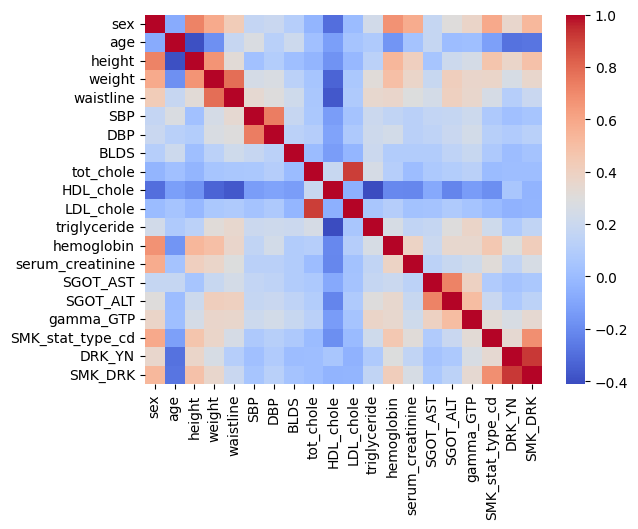

In [23]:
sd_cleaned.corr()
sns.heatmap(sd_cleaned.corr(), cmap='coolwarm')
plt.show()

checking how each of the columns we have to predict are distributed between their categories

In [9]:
y1 = sd_cleaned['DRK_YN']
y1.value_counts()

DRK_YN
0    483938
1    465298
Name: count, dtype: int64

In [10]:
y2 = sd_cleaned['SMK_stat_type_cd']
y2.value_counts()

SMK_stat_type_cd
1    587923
3    196488
2    164825
Name: count, dtype: int64

In [11]:
y3 = sd_cleaned['SMK_DRK']
y3.value_counts()

SMK_DRK
0    381214
3    206709
5    146263
4    112326
1     52499
2     50225
Name: count, dtype: int64

making columns for modelling the data

In [13]:
X = sd_cleaned.drop(['SMK_DRK', 'SMK_stat_type_cd', 'DRK_YN'], axis = 1)
X.head()

,sex,age,height,weight,waistline,SBP,DBP,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP
0,1,35,170,75,90.0,120,80,99,193,48,126,92,17.1,1.0,21,35,40
1,1,30,180,80,89.0,130,82,106,228,55,148,121,15.8,0.9,20,36,27
2,1,40,165,75,91.0,120,70,98,136,41,74,104,15.8,0.9,47,32,68
3,1,50,175,80,91.0,145,87,95,201,76,104,106,17.6,1.1,29,34,18
4,1,50,165,60,80.0,138,82,101,199,61,117,104,13.8,0.8,19,12,25


using undersampling to eliminate the effect of simbalanced data in our columns

In [14]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=1, sampling_strategy = 'majority')

X_a, y_a = rus.fit_resample(X,y1)
X_b, y_b = rus.fit_resample(X,y2)
X_c, y_c = rus.fit_resample(X,y3)

In [17]:
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(X_a, y_a, test_size = 0.2)
X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(X_b, y_b, test_size = 0.2)
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(X_c, y_c, test_size = 0.2)

Logistic Regression

In [30]:
from sklearn.linear_model import LogisticRegression

lr_a = LogisticRegression(max_iter = 4000)
lr_b = LogisticRegression(max_iter = 4000)
lr_c = LogisticRegression(max_iter = 4000)

lr_a.fit(X_a_train, y_a_train)
lr_b.fit(X_b_train, y_b_train)
lr_c.fit(X_c_train, y_c_train)

score_a = lr_a.score(X_a_test, y_a_test)
score_b = lr_b.score(X_b_test, y_b_test)
score_c = lr_c.score(X_c_test, y_c_test)



print('--------------------------------------------')
print('Test set drink')
print('-Score: %s' %score_a)
print('--------------------------------------------')
print('Test set smoke')
print('-Score: %s' %score_b)
print('--------------------------------------------')
print('Test set both')
print('-Score: %s' %score_c)

c:\Users\ashis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--------------------------------------------
Test set drink
-Score: 0.7228615946701054
--------------------------------------------
Test set smoke
-Score: 0.6436119663967765
--------------------------------------------
Test set both
-Score: 0.47362717347351396


c:\Users\ashis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--------------------------------------------
Test set drink
-Score: 0.7228615946701054
--------------------------------------------
Test set smoke
-Score: 0.6436119663967765
--------------------------------------------
Test set both
-Score: 0.47362717347351396

K Nearest Neighbors

In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn_a = KNeighborsClassifier(7)
knn_b = KNeighborsClassifier(7)
knn_c = KNeighborsClassifier(7)

knn_a.fit(X_a_train,y_a_train)
knn_b.fit(X_b_train,y_b_train)
knn_c.fit(X_c_train,y_c_train)

y_a_test_pred = knn_a.predict(X_a_test.values)
y_b_test_pred = knn_b.predict(X_b_test.values)
y_c_test_pred = knn_c.predict(X_c_test.values)

knn_a_test_accuracy = accuracy_score(y_a_test, y_a_test_pred)
knn_a_test_mcc = matthews_corrcoef(y_a_test, y_a_test_pred)
knn_b_test_accuracy = accuracy_score(y_b_test, y_b_test_pred)
knn_b_test_mcc = matthews_corrcoef(y_b_test, y_b_test_pred)
knn_c_test_accuracy = accuracy_score(y_c_test, y_c_test_pred)
knn_c_test_mcc = matthews_corrcoef(y_c_test, y_c_test_pred)

print('--------------------------------------------')
print('Test set drink')
print('-Accuracy: %s' %knn_a_test_accuracy)
print('-MCC: %s' %knn_a_test_mcc)
print('--------------------------------------------')
print('Test set smoke')
print('-Accuracy: %s' %knn_b_test_accuracy)
print('-MCC: %s' %knn_b_test_mcc)
print('--------------------------------------------')
print('Test set both')
print('-Accuracy: %s' %knn_c_test_accuracy)
print('-MCC: %s' %knn_c_test_mcc)

c:\Users\ashis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\ashis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
c:\Users\ashis\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


--------------------------------------------
Test set drink
-Accuracy: 0.6772942187835805
-MCC: 0.3547620371424609
--------------------------------------------
Test set smoke
-Accuracy: 0.5413958262059528
-MCC: 0.31062165867459396
--------------------------------------------
Test set both
-Accuracy: 0.38402749696724625
-MCC: 0.19308458527605687


--------------------------------------------
Test set drink
-Accuracy: 0.6772942187835805
-MCC: 0.3547620371424609
--------------------------------------------
Test set smoke
-Accuracy: 0.5413958262059528
-MCC: 0.31062165867459396
--------------------------------------------
Test set both
-Accuracy: 0.38402749696724625
-MCC: 0.19308458527605687

In [35]:
from sklearn.tree import DecisionTreeClassifier

dt_a = DecisionTreeClassifier(max_depth = 10)
dt_b = DecisionTreeClassifier(max_depth = 10)
dt_c = DecisionTreeClassifier(max_depth = 10)

dt_a.fit(X_a_train, y_a_train)
dt_b.fit(X_b_train, y_b_train)
dt_c.fit(X_c_train, y_c_train)

y_a_test_pred = dt_a.predict(X_a_test)
y_b_test_pred = dt_b.predict(X_b_test)
y_c_test_pred = dt_c.predict(X_c_test)

dt_a_test_accuracy = accuracy_score(y_a_test, y_a_test_pred)
dt_a_test_mcc = matthews_corrcoef(y_a_test, y_a_test_pred)
dt_b_test_accuracy = accuracy_score(y_b_test, y_b_test_pred)
dt_b_test_mcc = matthews_corrcoef(y_b_test, y_b_test_pred)
dt_c_test_accuracy = accuracy_score(y_c_test, y_c_test_pred)
dt_c_test_mcc = matthews_corrcoef(y_c_test, y_c_test_pred)

print('--------------------------------------------')
print('Test set drink')
print('-Accuracy: %s' %dt_a_test_accuracy)
print('-MCC: %s' %dt_a_test_mcc)
print('--------------------------------------------')
print('Test set smoke')
print('-Accuracy: %s' %dt_b_test_accuracy)
print('-MCC: %s' %dt_b_test_mcc)
print('--------------------------------------------')
print('Test set both')
print('-Accuracy: %s' %dt_c_test_accuracy)
print('-MCC: %s' %dt_c_test_mcc)

--------------------------------------------
Test set drink
-Accuracy: 0.7207178164624973
-MCC: 0.44201493610325826
--------------------------------------------
Test set smoke
-Accuracy: 0.6355342684456609
-MCC: 0.45064685992267284
--------------------------------------------
Test set both
-Accuracy: 0.46771532551556816
-MCC: 0.3020447861637841


--------------------------------------------
Test set drink
-Accuracy: 0.7207178164624973
-MCC: 0.44201493610325826
--------------------------------------------
Test set smoke
-Accuracy: 0.6355342684456609
-MCC: 0.45064685992267284
--------------------------------------------
Test set both
-Accuracy: 0.46771532551556816
-MCC: 0.3020447861637841

Random Forest Classifier

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_a= RandomForestClassifier(n_estimators = 10)
rf_b= RandomForestClassifier(n_estimators = 10)
rf_c= RandomForestClassifier(n_estimators = 10)

rf_a.fit(X_a_train, y_a_train)
rf_b.fit(X_b_train, y_b_train)
rf_c.fit(X_c_train, y_c_train)

y_a_test_pred = rf_a.predict(X_a_test)
y_b_test_pred = rf_b.predict(X_b_test)
y_c_test_pred = rf_c.predict(X_c_test)

rf_a_test_accuracy = accuracy_score(y_a_test, y_a_test_pred)
rf_a_test_mcc = matthews_corrcoef(y_a_test, y_a_test_pred)
rf_b_test_accuracy = accuracy_score(y_b_test, y_b_test_pred)
rf_b_test_mcc = matthews_corrcoef(y_b_test, y_b_test_pred)
rf_c_test_accuracy = accuracy_score(y_c_test, y_c_test_pred)
rf_c_test_mcc = matthews_corrcoef(y_c_test, y_c_test_pred)


print('--------------------------------------------')
print('Test set drink')
print('-Accuracy: %s' %rf_a_test_accuracy)
print('-MCC: %s' %rf_a_test_mcc)
print('--------------------------------------------')
print('Test set smoke')
print('-Accuracy: %s' %rf_b_test_accuracy)
print('-MCC: %s' %rf_b_test_mcc)
print('--------------------------------------------')
print('Test set both')
print('-Accuracy: %s' %rf_c_test_accuracy)
print('-MCC: %s' %rf_c_test_mcc)

--------------------------------------------
Test set drink
-Accuracy: 0.6978830861809585
-MCC: 0.3976462560052327
--------------------------------------------
Test set smoke
-Accuracy: 0.6132873379708823
-MCC: 0.4181698208803
--------------------------------------------
Test set both
-Accuracy: 0.4298584714921148
-MCC: 0.25475260857080223


--------------------------------------------
Test set drink
-Accuracy: 0.6978830861809585
-MCC: 0.3976462560052327
--------------------------------------------
Test set smoke
-Accuracy: 0.6132873379708823
-MCC: 0.4181698208803
--------------------------------------------
Test set both
-Accuracy: 0.4298584714921148
-MCC: 0.25475260857080223

Support Vector Machines

In [39]:
from sklearn.svm import SVC

svm_rbf_a = SVC(gamma=2, C=1)
svm_rbf_b = SVC(gamma=2, C=1)
svm_rbf_c = SVC(gamma=2, C=1)
svm_rbf_a.fit(X_a_train,y_a_train)
svm_rbf_b.fit(X_b_train,y_b_train)
svm_rbf_c.fit(X_c_train,y_c_train)

y_a_test_pred = svm_rbf_a.predict(X_a_test)
y_b_test_pred = svm_rbf_b.predict(X_b_test)
y_c_test_pred = svm_rbf_c.predict(X_c_test)

svm_rbf_a_test_accuracy = accuracy_score(y_a_test, y_a_test_pred)
svm_rbf_a_test_mcc = matthews_corrcoef(y_a_test, y_a_test_pred)
svm_rbf_b_test_accuracy = accuracy_score(y_b_test, y_b_test_pred)
svm_rbf_b_test_mcc = matthews_corrcoef(y_b_test, y_b_test_pred)
svm_rbf_c_test_accuracy = accuracy_score(y_c_test, y_c_test_pred)
svm_rbf_c_test_mcc = matthews_corrcoef(y_c_test, y_c_test_pred)


print('--------------------------------------------')
print('Test set')
print('-Accuracy: %s' %svm_rbf_a_test_accuracy)
print('-MCC: %s' %svm_rbf_a_test_mcc)
print('--------------------------------------------')
print('Test set smoke')
print('-Accuracy: %s' %svm_rbf_b_test_accuracy)
print('-MCC: %s' %svm_rbf_b_test_mcc)
print('--------------------------------------------')
print('Test set both')
print('-Accuracy: %s' %svm_rbf_c_test_accuracy)
print('-MCC: %s' %svm_rbf_c_test_mcc)

: 

Multi Level Perceptron

In [18]:
from sklearn.neural_network import MLPClassifier
mlp_a = MLPClassifier()
mlp_b = MLPClassifier()
mlp_c = MLPClassifier()

mlp_a.fit(X_a_train, y_a_train)
mlp_b.fit(X_b_train, y_b_train)
mlp_c.fit(X_c_train, y_c_train)

y_a_test_pred = mlp_a.predict(X_a_test)
y_b_test_pred = mlp_b.predict(X_b_test)
y_c_test_pred = mlp_c.predict(X_c_test)

mlp_a_test_accuracy = accuracy_score(y_a_test, y_a_test_pred)
mlp_a_test_mcc = matthews_corrcoef(y_a_test, y_a_test_pred)
mlp_b_test_accuracy = accuracy_score(y_b_test, y_b_test_pred)
mlp_b_test_mcc = matthews_corrcoef(y_b_test, y_b_test_pred)
mlp_c_test_accuracy = accuracy_score(y_c_test, y_c_test_pred)
mlp_c_test_mcc = matthews_corrcoef(y_c_test, y_c_test_pred)

print('--------------------------------------------')
print('Test set drink')
print('-Accuracy: %s' %mlp_a_test_accuracy)
print('-MCC: %s' %mlp_a_test_mcc)

print('--------------------------------------------')
print('Test set smoke')
print('-Accuracy: %s' %mlp_b_test_accuracy)
print('-MCC: %s' %mlp_b_test_mcc)

print('--------------------------------------------')
print('Test set both')
print('-Accuracy: %s' %mlp_c_test_accuracy)
print('-MCC: %s' %mlp_c_test_mcc)

I would have done linear regression model also but logical is better for classification so I did not do it.
another way I could've dealt with the data is do pca to reduce the dimensions so that the data becomes easier to deal with. I ran all the models that were possible for my machine to run. svm and mlp took a lot of time to process and still didnt give the outputs so I dont have the outputs for them. the outputs for all the rest should be given, if not I have written them down in then file.